In [2]:
def aggregate_to_5km(raster, agg_type="mean",return_qa_array=False,chunk_rows=500):
    
    """
    Aggregate a large raster to a 5 km grid without loading the
    entire raster into memory.

    Parameters
    ----------
    raster : xarray.DataArray
        Input raster with x/y coordinates.
    agg_type : str
        "mean" or "mode".
    return_qa_array : bool
        If True, returns mapping of input pixels -> 5 km cell index.
        WARNING: this can itself be very large for high-resolution data.
    chunk_rows : int
        Number of raster rows to process at a time.

    Returns
    -------
    xarray.Dataset
        Aggregated result.
    """
    
    
    # ------------------------------------------------------------
    # Load 5 km grid
    # ------------------------------------------------------------

    ds = xr.open_dataset(GRID_5KM_FILE)

    x5 = ds["projection_x_coordinate"].values
    y5 = ds["projection_y_coordinate"].values

    nx = len(x5)
    ny = len(y5)

    n_cells = nx * ny

    # ------------------------------------------------------------
    # Input raster coordinates
    # ------------------------------------------------------------

    x = raster["x"].values
    y = raster["y"].values

    n_y = len(y)
    n_x = len(x)

    # ------------------------------------------------------------
    # Accumulators
    # ------------------------------------------------------------

    if agg_type == "mean":

        sums = np.zeros(n_cells, dtype=np.float64)
        counts = np.zeros(n_cells, dtype=np.int64)

    elif agg_type == "mode":

        vals_are_integer = True

        # Determine possible categorical values.
        # Your soil texture has classes 0-11, so this is tiny.
        max_class = 11

        class_counts = np.zeros(
            (max_class + 1, n_cells),
            dtype=np.int64)

    else:
        raise ValueError("agg_type must be 'mean' or 'mode'")

    # ------------------------------------------------------------
    # Optional QA array
    # ------------------------------------------------------------

    if return_qa_array:
        qa = np.full((n_y, n_x), -1, dtype=np.int32)

        
    # ------------------------------------------------------------
    # Process raster in chunks
    # ------------------------------------------------------------

    for y_start in tqdm(
        range(0, n_y, chunk_rows),
        desc="Processing raster"):

        y_end = min(y_start + chunk_rows, n_y)

        # Only load this chunk from the raster
        chunk = raster.isel(
            y=slice(y_start, y_end))

        vals = chunk.values

        # Coordinates for this chunk only
        y_chunk = y[y_start:y_end]

        # --------------------------------------------------------
        # Create coordinates without creating full-size meshgrid
        # --------------------------------------------------------

        # Repeat x for each row
        x_flat = np.tile(x, len(y_chunk))

        # Repeat each y coordinate across all x values
        y_flat = np.repeat(y_chunk, n_x)

        vals_flat = vals.ravel()

        # --------------------------------------------------------
        # Remove NaNs
        # --------------------------------------------------------

        valid = ~np.isnan(vals_flat)

        x_flat = x_flat[valid]
        y_flat = y_flat[valid]
        vals_flat = vals_flat[valid]

        # --------------------------------------------------------
        # Map input pixels to 5 km cells
        # --------------------------------------------------------

        ix = np.searchsorted(x5, x_flat) - 1
        iy = np.searchsorted(y5, y_flat) - 1

        valid_idx = ((ix >= 0) &(ix < nx) &(iy >= 0) &(iy < ny))

        ix = ix[valid_idx]
        iy = iy[valid_idx]
        vals_flat = vals_flat[valid_idx]

        # Linear 5 km cell index
        linear_idx = iy * nx + ix

        # --------------------------------------------------------
        # Mean
        # --------------------------------------------------------

        if agg_type == "mean":

            sums += np.bincount( linear_idx, weights=vals_flat, minlength=n_cells )

            counts += np.bincount(     linear_idx,     minlength=n_cells)

        # --------------------------------------------------------
        # Mode
        # --------------------------------------------------------

        elif agg_type == "mode":

            vals_int = vals_flat.astype(np.int16)

            # Count each category separately
            for category in range(max_class + 1):

                category_mask = vals_int == category

                if not np.any(category_mask):
                    continue

                category_cells = linear_idx[category_mask]

                class_counts[category] += np.bincount(category_cells, minlength=n_cells )

        # --------------------------------------------------------
        # QA
        # --------------------------------------------------------

        if return_qa_array:

            # Need the original chunk-sized mapping
            chunk_linear_idx = np.full(vals.size,  -1,  dtype=np.int32)

            # Recreate mapping for all pixels in chunk
            xx_flat = np.tile(x, len(y_chunk))
            yy_flat = np.repeat(y_chunk, n_x)

            ix_all = np.searchsorted(x5, xx_flat) - 1
            iy_all = np.searchsorted(y5, yy_flat) - 1

            valid_all = (
                (ix_all >= 0) &
                (ix_all < nx) &
                (iy_all >= 0) &
                (iy_all < ny))

            chunk_linear_idx[valid_all] = (
                iy_all[valid_all] * nx +
                ix_all[valid_all])

            qa[y_start:y_end, :] = chunk_linear_idx.reshape(
                len(y_chunk),
                n_x)

    # ============================================================
    # Construct output
    # ============================================================

    if agg_type == "mean":

        mean_vals = np.full(
            n_cells,
            np.nan,
            dtype=np.float64)

        mask = counts > 0

        mean_vals[mask] = (
            sums[mask] / counts[mask])

        out = mean_vals.reshape(ny, nx)

        ds_out = xr.Dataset({"aggregated_mean": (("projection_y_coordinate", "projection_x_coordinate"), out)})

    elif agg_type == "mode":

        # Most common category
        mode_vals = np.full(n_cells, np.nan, dtype=np.float64)

        mode_prop = np.full(n_cells, np.nan, dtype=np.float64)

        total_counts = class_counts.sum(axis=0)

        valid_cells = total_counts > 0

        mode_vals[valid_cells] = (np.argmax( class_counts[:, valid_cells],axis=0))

        mode_counts = class_counts[
            np.argmax(class_counts, axis=0),
            np.arange(n_cells)]

        mode_prop[valid_cells] = (
            mode_counts[valid_cells] /
            total_counts[valid_cells])

        ds_out = xr.Dataset({"mode": ( ( "projection_y_coordinate", "projection_x_coordinate"),mode_vals.reshape(ny, nx)),

            "mode_proportion": (("projection_y_coordinate","projection_x_coordinate"),mode_prop.reshape(ny, nx))})

    # ------------------------------------------------------------
    # Assign coordinates
    # ------------------------------------------------------------

    ds_out = ds_out.assign_coords({"projection_x_coordinate": x5, "projection_y_coordinate": y5})

    # ------------------------------------------------------------
    # Return
    # ------------------------------------------------------------

    if return_qa_array:
        return ds_out, qa

    return ds_out

GRID_5KM_FILE = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall/5km/Ens_01/bc_pr_rcp85_land-cpm_uk_5km_01_1hr_19901201-19911130.nc"

In [3]:
# NEED TO RUN THIS WITHIN FUTUREFLOOD_CLEAN

In [1]:
import os
import rioxarray as rxr
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import iris
import iris.plot as iplt
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import re
from tqdm import tqdm
from rioxarray.merge import merge_arrays

SOIL_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
CATCHMENT_DIR = "/scratch/hydro4/users/kv25483/FutureFlood/Data/CatchmentShapefiles/"

from functions import aggregate_to_5km, convert_to_netcdf

### Get hydraulic conductivity lookup

In [3]:
soils_lookup = pd.read_csv("../../Data/Soil_Info.csv")

# 1. Build a lookup dictionary from the CSV
#    adjust column name to match your actual hydraulic conductivity column
hc_lookup = dict(zip(
    soils_lookup["USDA_soil"],
    soils_lookup["Hydraulic_conductivity"]))

ep_lookup = dict(zip(
    soils_lookup["USDA_soil"],
    soils_lookup["Effective_porosity"]))

### Get catchment data

In [4]:
catchments = gpd.read_file(CATCHMENT_DIR + "hyd_areas_GB_with_subcatchments.shp")
ha_nums = catchments['HA_NUM']

### Join soil texture, hydraulic conductiity and effective porosity data over GB

In [5]:
hk_rasters_30m = []
ep_rasters_30m = []
texture_rasters_30m = [] 
max_texture = 0  

for ha_num in tqdm(ha_nums): 
    soil_file = SOIL_DIR + f"soil_30m_{ha_num}.tif" 
    if not os.path.exists(soil_file): 
        continue 
   
    # Get soil texture data 
    soil_texture = rxr.open_rasterio(soil_file).squeeze() 
    # avoid dask chunks here; merge wants computed arrays 
    soil_texture = soil_texture.where(soil_texture != -9999) 
    soil_values = soil_texture.values 
    if np.nanmax(soil_values) >max_texture:
        max_texture = np.nanmax(soil_values)
        print(max_texture)
    
    #####################
    # Convert to HC values
    #####################
    hk_values = np.full(soil_values.shape, np.nan, dtype=np.float32) 
    
    for usda_class, hk in hc_lookup.items(): 
        hk_values[soil_values == usda_class] = hk 
        
    hk_raster = soil_texture.copy(data=hk_values) 
    hk_raster.name = "hydraulic_conductivity" 
    hk_raster.rio.write_crs(soil_texture.rio.crs, inplace=True) 
    hk_raster.attrs["units"] = "cm hr-1"
    hk_raster.attrs["source"] = "Rawls et al. (1983) lookup by USDA soil texture class"
    
    #####################
    # Convert to EP values
    #####################
    ep_values = np.full(soil_values.shape, np.nan, dtype=np.float32) 
    
    for usda_class, ep in ep_lookup.items(): 
        ep_values[soil_values == usda_class] = ep 
        
    ep_raster = soil_texture.copy(data=ep_values) 
    ep_raster.name = "effective_porosity" 
    ep_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)     
    ep_raster.attrs["units"] = "cm3 cm-3"
    
    hk_rasters_30m.append(hk_raster)  
    ep_rasters_30m.append(ep_raster) 
    texture_rasters_30m.append(soil_texture) 
        
national_hc_30m = merge_arrays(hk_rasters_30m, nodata=np.nan) 
national_hc_30m.name = "hydraulic_conductivity" 

national_ep_30m = merge_arrays(ep_rasters_30m, nodata=np.nan) 
national_ep_30m.name = "effective_porosity" 

national_texture_30m = merge_arrays(texture_rasters_30m, nodata=np.nan) 
national_texture_30m.name = "soil_texture" 


  0%|                                                                                                                              | 0/114 [00:00<?, ?it/s]

9.0


  2%|██                                                                                                                    | 2/114 [00:01<00:53,  2.08it/s]

12.0


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 114/114 [00:27<00:00,  4.07it/s]


### Aggregate to 5km

In [6]:
# Continuous
# hk_5km = aggregate_to_5km(national_hc_30cm, agg_type="mean")

# Categorical
# ep_5km = aggregate_to_5km(national_ep_30m,agg_type="mean")

# # Categorical
texture_5km = aggregate_to_5km(national_texture_30m, agg_type="mode")

Processing raster: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 71/71 [00:15<00:00,  4.50it/s]


### Check plotting

In [9]:
np.nanmax(texture_5km['mode'])

np.float64(11.0)

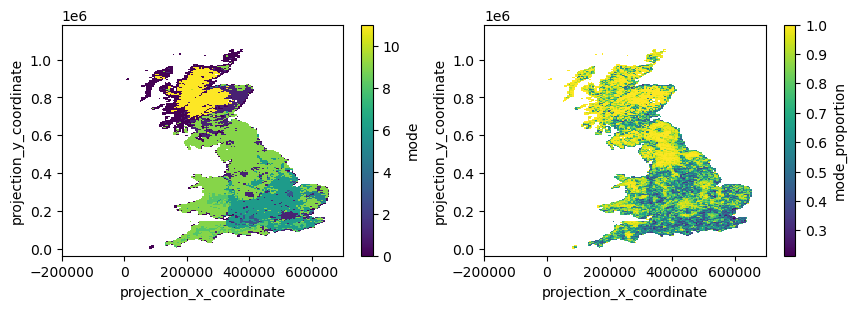

In [34]:
# hk_5km["aggregated_mean"].plot()
# ep_5km["aggregated_mean"].plot()

fig,axs=plt.subplots(ncols=2, figsize=(10,3))
texture_5km["mode"].plot(ax=axs[0])
texture_5km["mode_proportion"].plot(ax=axs[1]);

### Convert to a netCDF and save to file

In [39]:
# hk_5km['aggregated_mean'].to_netcdf("../../Data/HydraulicConductivity/GB_5km_new.nc")
ep_5km['aggregated_mean'].to_netcdf("../../Data/EffectivePorosity/GB_5km_mean.nc")
texture_5km['mode'].to_netcdf("../../Data/SoilTexture/GB_5km_mode.nc")
texture_5km['mode_proportion'].to_netcdf("../../Data/SoilTexture/GB_5km_mode_prop.nc")

### Read back in and check

In [40]:
# test_ep_5km = xr.open_dataset("../../Data/EffectivePorosity/GB_5km_mode.nc")
# print(np.nanmin(test_ep_5km['mode'].data))
# print(np.nanmax(test_ep_5km['mode'].data))

# print(np.nanmin(ep_5km['mode'].data))
# print(np.nanmax(ep_5km['mode'].data))

In [72]:
test_hc_5km = xr.open_dataset("../../Data/HydraulicConductivity/GB_5km_new.nc")
print(np.nanmin(test_hc_5km['aggregated_mean'].data))
print(np.nanmax(test_hc_5km['aggregated_mean'].data))

print(np.nanmin(hk_5km['aggregated_mean'].data))
print(np.nanmax(hk_5km['aggregated_mean'].data))

0.029999999329447746
7.628403453972807
0.029999999329447746
7.628403453972807


In [43]:
test_texture_5km = xr.open_dataset("../../Data/SoilTexture/5km_GB_mode.nc")
print(np.nanmin(test_texture_5km['mode'].data))
print(np.nanmax(test_texture_5km['mode'].data))

print(np.nanmin(texture_5km['mode'].data))
print(np.nanmax(texture_5km['mode'].data))

0.0
12.0
0.0
11.0


In [ ]:
np.nnamax(national_texture_30m)

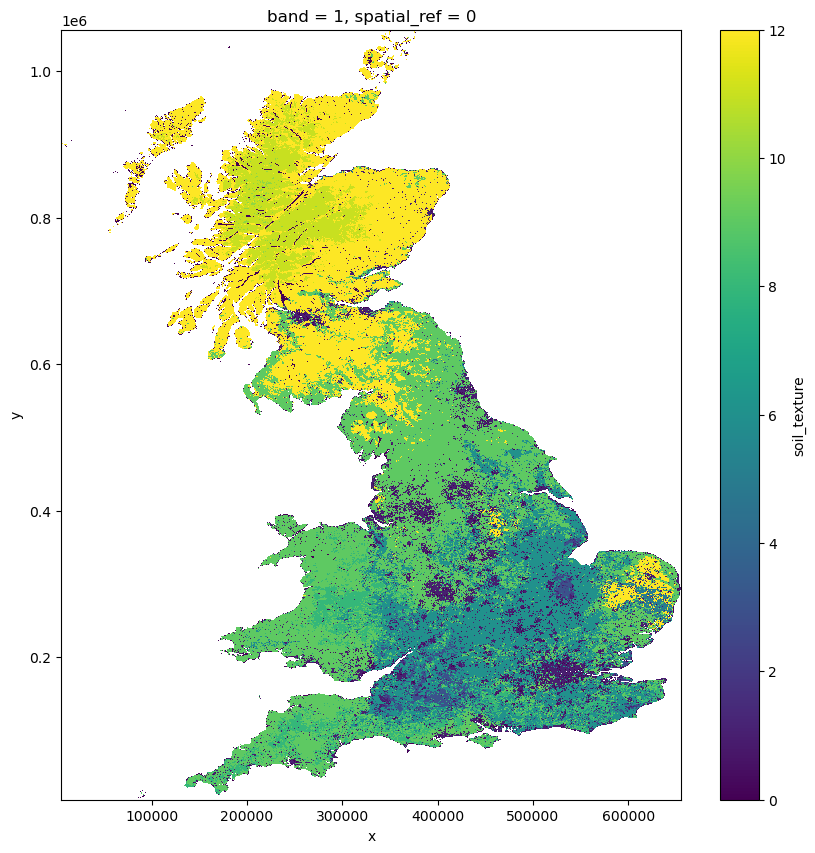

In [10]:
# plt.pcolormesh(national_texture_30m, cmap = 'viridis')
import matplotlib.pyplot as plt

plot_texture = national_texture_30m.isel(
    y=slice(None, None, 20),
    x=slice(None, None, 20)
)

plt.figure(figsize=(10, 10))

plot_texture.plot(
    cmap="viridis",
    add_colorbar=True
)

plt.show()

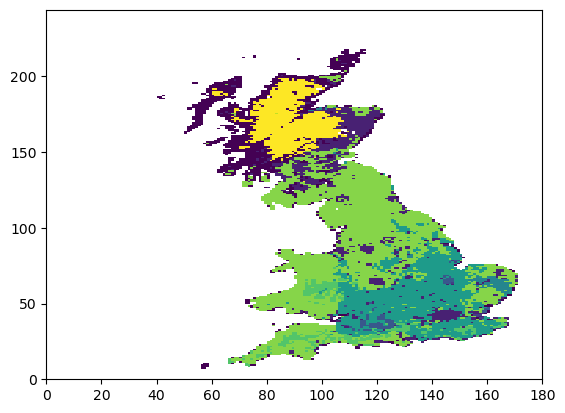

In [11]:
plt.pcolormesh(texture_5km['mode'], cmap = 'viridis')

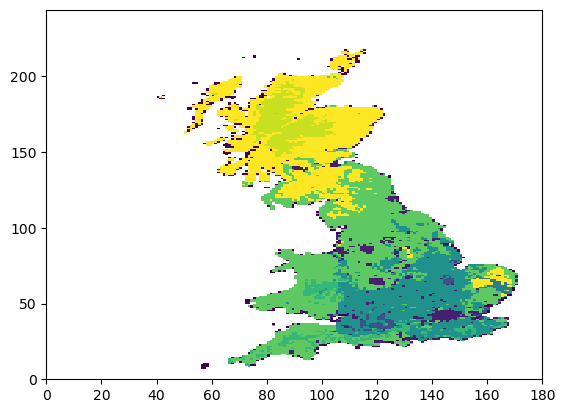

In [60]:
plt.pcolormesh(test_texture_5km['mode'], cmap = 'viridis')